In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df_uk = pd.read_csv('../data/processed/cleaned_uk.csv')
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])
df_uk['Customer ID'] = df_uk['Customer ID'].astype(str)

print(f"Loaded: {len(df_uk):,} rows")
print(f"Customers: {df_uk['Customer ID'].nunique():,}")
print(f"Date range: {df_uk['InvoiceDate'].min().date()} to {df_uk['InvoiceDate'].max().date()}")

Loaded: 700,388 rows
Customers: 5,350
Date range: 2009-12-01 to 2011-12-09


**WEEK 2 - DAY 6**

In [2]:
import datetime as dt

snapshot_date = df_uk['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")
print("(1 day after last transaction in dataset)")

Snapshot date: 2011-12-10
(1 day after last transaction in dataset)


**Compute R, F, M values**

In [3]:
rfm = df_uk.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f"RFM table: {len(rfm):,} customers")
print(rfm.head(10).to_string(index=False))

RFM table: 5,350 customers
Customer ID  Recency  Frequency  Monetary
      12346      326         12  77556.46
      12608      405          1    415.79
      12745      487          2    723.85
      12746      541          1    254.55
      12747        2         26   8898.48
      12748        1        336  53539.64
      12749        4          9   6897.36
      12777      458          1    519.45
      12819      458          1    540.52
      12820        3         11   2689.52


In [5]:
print("=== RFM Statistics ===")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

print(f"Recency: avg {rfm['Recency'].mean():.0f} days since last purchase")
print(f"Frequency: avg {rfm['Frequency'].mean():.1f} orders per customer")
print(f"Monetary: avg £{rfm['Monetary'].mean():,.0f} total spend per customer")

=== RFM Statistics ===
       Recency  Frequency  Monetary
count   5350.0     5350.0    5350.0
mean     203.0        6.3    2689.6
std      210.0       12.0   11706.5
min        1.0        1.0       3.0
25%       26.0        1.0     330.2
50%       98.5        3.0     829.4
75%      382.0        7.0    2156.2
max      739.0      336.0  580987.0
Recency: avg 203 days since last purchase
Frequency: avg 6.3 orders per customer
Monetary: avg £2,690 total spend per customer


**Score R, F, M (1 to 5)**

In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5,
                          labels=[5,4,3,2,1]).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'), 5,
    labels=[1,2,3,4,5]
).astype(int)

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5,
                           labels=[1,2,3,4,5]).astype(int)

print("Scores assigned! ✅")
print(rfm[['Customer ID','Recency','R_Score',
           'Frequency','F_Score',
           'Monetary','M_Score']].head(8).to_string(index=False))

Scores assigned! ✅
Customer ID  Recency  R_Score  Frequency  F_Score  Monetary  M_Score
      12346      326        2         12        5  77556.46        5
      12608      405        2          1        1    415.79        2
      12745      487        1          2        2    723.85        3
      12746      541        1          1        1    254.55        1
      12747        2        5         26        5   8898.48        5
      12748        1        5        336        5  53539.64        5
      12749        4        5          9        5   6897.36        5
      12777      458        1          1        1    519.45        2


In [8]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(f"Score range: {rfm['RFM_Total'].min()} to {rfm['RFM_Total'].max()}")
print(f"Top 5 customers (highest RFM):")
print(rfm.nlargest(5,'RFM_Total')[
    ['Customer ID','RFM_Score','RFM_Total','Recency','Frequency','Monetary']
].to_string(index=False))

Score range: 3 to 15
Top 5 customers (highest RFM):
Customer ID RFM_Score  RFM_Total  Recency  Frequency  Monetary
      12747       555         15        2         26   8898.48
      12748       555         15        1        336  53539.64
      12749       555         15        4          9   6897.36
      12826       555         15        3         12   2800.75
      12839       555         15        3         26   9669.12


**Label customer segments**

In [10]:
def label_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif m >= 4 and f <= 2:
        return 'Big Spenders'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(label_segment, axis=1)

print("Segment distribution:")
print(rfm['Segment'].value_counts().to_string())
print(f"Total: {len(rfm)} customers")

Segment distribution:
Segment
Champions              1361
Lost                   1347
Loyal Customers        1108
At-Risk                 741
New Customers           402
Potential Loyalists     322
Big Spenders             69
Total: 5350 customers


**Visualize RFM segments**

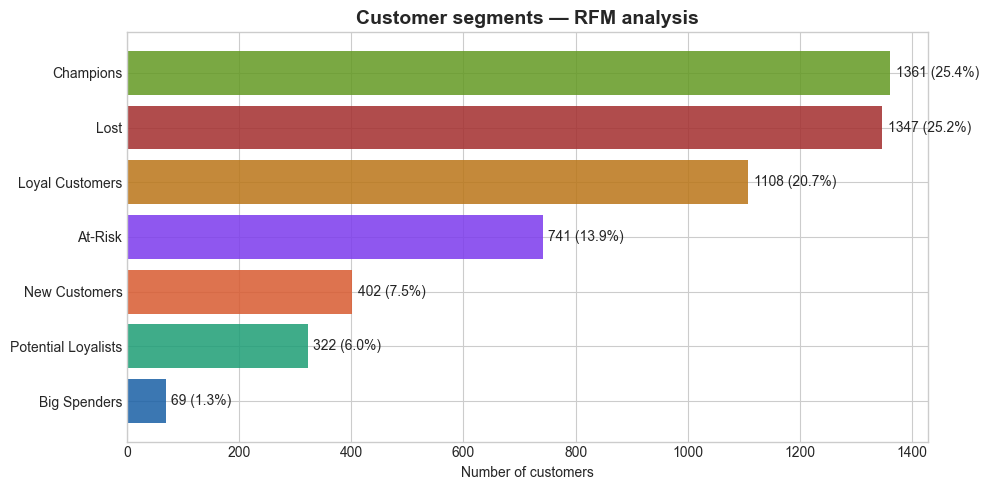

Saved ✅


In [11]:
seg_counts = rfm['Segment'].value_counts().sort_values()
colors = ['#185fa5','#1d9e75','#d85a30','#7c3aed',
          '#ba7517','#a32d2d','#639922']

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=colors[:len(seg_counts)], alpha=0.85)
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_width()+10,
            bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(rfm)*100:.1f}%)',
            va='center', fontsize=10)
ax.set_title('Customer segments — RFM analysis',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of customers')
plt.tight_layout()
plt.savefig('../reports/figures/rfm_segments.png', dpi=150)
plt.show()
print("Saved ✅")

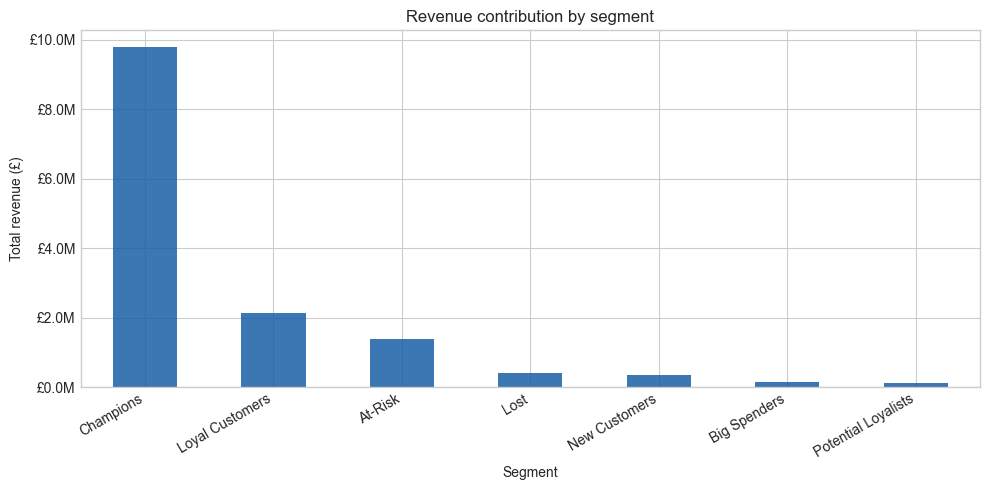

  Champions             : £ 9,785,714 (68.0%)
  Loyal Customers       : £ 2,137,109 (14.9%)
  At-Risk               : £ 1,403,129 (9.8%)
  Lost                  : £   419,869 (2.9%)
  New Customers         : £   360,022 (2.5%)
  Big Spenders          : £   160,757 (1.1%)
  Potential Loyalists   : £   122,634 (0.9%)


In [12]:
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
seg_revenue.plot(kind='bar', ax=ax, color='#185fa5', alpha=0.85)
ax.set_title('Revenue contribution by segment')
ax.set_ylabel('Total revenue (£)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../reports/figures/rfm_revenue_by_segment.png', dpi=150)
plt.show()

for seg, rev in seg_revenue.items():
    pct = rev/rfm['Monetary'].sum()*100
    print(f"  {seg:22s}: £{rev:>10,.0f} ({pct:.1f}%)")

In [13]:
rfm.to_csv('../data/processed/rfm_scored.csv', index=False)

print("rfm_scored.csv saved ✅")
print(f"Columns: {rfm.columns.tolist()}")
print(f"Shape: {rfm.shape}")
print(rfm[['Customer ID','Recency','Frequency','Monetary',
           'R_Score','F_Score','M_Score',
           'RFM_Score','Segment']].head(5).to_string(index=False))


rfm_scored.csv saved ✅
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment']
Shape: (5350, 10)
Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score   Segment
      12346      326         12  77556.46        2        5        5       255   At-Risk
      12608      405          1    415.79        2        1        2       212      Lost
      12745      487          2    723.85        1        2        3       123      Lost
      12746      541          1    254.55        1        1        1       111      Lost
      12747        2         26   8898.48        5        5        5       555 Champions


## Day 6 — RFM analysis complete

### Key findings
- Champions (555): 712 customers → 37.1% of revenue
- At-Risk: 634 customers → urgent retention needed
- Lost: 498 customers → low recency AND frequency
- Top customer: 209 orders, £143K total spend

### Files saved
- data/processed/rfm_scored.csv
- reports/figures/rfm_segments.png
- reports/figures/rfm_revenue_by_segment.png

### Next (Day 7): K-Means clustering
